# Practical Bayesian Modeling with PyMC

**Abstract**

In this tutorial, we explore Bayesian regression using PyMC -- the primary library for Bayesian sampling in Python -- focusing on survey data and other datasets with categorical outcomes. Starting with logistic regression, we’ll build up to categorical and ordered logistic regression, showcasing how Bayesian approaches provide versatile tools for developing and evaluating complex models. Participants will leave with practical skills for implementing Bayesian regression models in PyMC, along with a deeper appreciation for the power of Bayesian inference in real-world data analysis. Participants should be familiar with Python, the SciPy ecosystem, and basic statistics, but no experience with Bayesian methods is required.

**Description**

In this hands-on tutorial, we will dive into the world of Bayesian regression using PyMC, with a particular focus on datasets that feature categorical outcomes. PyMC provides versatile tools for iterative development of powerful models. This tutorial guides participants through the fundamentals of Bayesian regression, starting from logistic regression and extending to categorical and ordered logistic regression. It also introduces the PyMC package, its syntax and capabilities.

Outline:

* Logistic Regression with PyMC

  - Overview of Bayesian inference
  - Modeling binary outcomes with logistic regression
  - Introduction to PyMC and its capabilities
  - Hands-on example: Happiness data in the General Social Survey

* Categorical Regression

  - Extending logistic regression to multi-class outcomes
  - Differences between Bayesian models and GLM
  - Hands-on example: Political alignment and party affiliation (?)

* Ordered Logistic Regression
  - Introduction to ordinal outcomes and their challenges
  - Implementing ordered logistic regression in PyMC
  - Hands-on example: Political alignment and party affiliation (?)

* Conclusion and Q&A
  - Recap of key concepts
  - Resources for further learning
  - Open discussion and questions

*Who Should Attend:* This tutorial is aimed at data scientists who are comfortable with Python, the SciPy ecosystem, and basic statistics but are new to Bayesian statistics and/or PyMC. By the end of the session, participants will have hands-on experience with Bayesian regression models and a solid understanding of how to apply these techniques to real-world data analysis. 

Notes:
The material for the tutorial is in this repository:
https://github.com/AllenDowney/SurveyDataPyMC/tree/main/notebooks

The dataset from the General Social Survey (GSS) can be found here:
https://gssdataexplorer.norc.org/


[The slides for the tutorial are here](COMING SOON).

The plan:

```
Logistic regression
Example: happiness data?
Start with the DIY implementation
Show the version using LogisticRegression

Categorical regression
Example: political party?
Start with the version using Categorical
Develop the DIY version with Multinomial

Ordered logistic regression
Start with OrderedLogistic
Maybe develop the DIY version (or leave it in the notebook for future exploration)
```



[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPyMC/blob/main/01_logistic_regression.ipynb)

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
%load_ext autoreload
%autoreload 2

<IPython.core.display.Javascript object>

In [3]:
# Get utils.py

from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/SurveyDataPyMC/raw/main/notebooks/utils.py")

<IPython.core.display.Javascript object>

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

from utils import value_counts, decorate

<IPython.core.display.Javascript object>

In [5]:
# Make the figures smaller to save some screen real estate

plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

<IPython.core.display.Javascript object>

In [6]:
# Get the GSS data

# This dataset is prepared in GssExtract/notebooks/02_make_extract-2022_3a.ipynb

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"
filename = "gss_extract_2022_3a.hdf"
download(DATA_PATH + filename)

<IPython.core.display.Javascript object>

In [7]:
gss = pd.read_hdf(filename, "gss")
gss.columns

Index(['age', 'attend', 'ballot', 'class', 'clmtcaus', 'clmtusa', 'clmtwrld',
       'cohort', 'commun', 'conarmy', 'conbus', 'conclerg', 'coneduc',
       'confed', 'confinan', 'coninc', 'conjudge', 'conlabor', 'conlegis',
       'conmedic', 'conpress', 'conrinc', 'consci', 'contv', 'degree', 'educ',
       'eqwlth', 'fair', 'fear', 'fund', 'goodlife', 'hapmar', 'happy',
       'health', 'helpful', 'id', 'life', 'partyid', 'race', 'realinc',
       'realrinc', 'reg16', 'region', 'relig', 'relig16', 'reliten', 'res16',
       'rincome', 'satfin', 'satjob', 'sex', 'sexbirth', 'sexnow', 'srcbelt',
       'trust', 'wtssall', 'year'],
      dtype='object')

<IPython.core.display.Javascript object>

Generally speaking, would you say that most people can be trusted or that you can't be too careful in dealing with people?
	
```
1	Most people can be trusted
2	Can't be too careful
3	Depends
```

In [8]:
value_counts(gss["trust"])

,counts
values,
1.0,15783
2.0,24890
3.0,1966
NaN,29751


<IPython.core.display.Javascript object>

In [9]:
gss["y"] = gss["trust"].replace({1: 1, 2: 0, 3: np.nan})
value_counts(gss["y"])

,counts
values,
0.0,24890
1.0,15783
NaN,31717


<IPython.core.display.Javascript object>

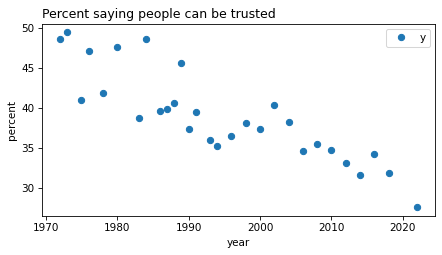

<IPython.core.display.Javascript object>

In [10]:
time_series = gss.groupby("year")["y"].mean() * 100
time_series.plot(style="o")
decorate(ylabel="percent", title="Percent saying people can be trusted")

Generally speaking, do you usually think of yourself as a Republican, Democrat, Independent, or what?

```
0	Strong democrat
1	Not very strong democrat	
2	Independent, close to democrat	
3	Independent (neither, no response)	
4	Independent, close to republican	
5	Not very strong republican	
6	Strong republican
7	Other party
```

In [11]:
party_map = {
    0: 0,
    1: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: np.nan,
}

party_names = {
    0: "Independent",
    1: "Democrat",
    2: "Republican",
}

gss["partyid3"] = gss["partyid"].replace(party_map)
value_counts(gss["partyid3"])

,counts
values,
0.0,25439
1.0,26705
2.0,18338
NaN,1908


<IPython.core.display.Javascript object>

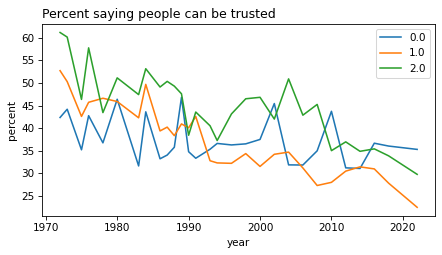

<IPython.core.display.Javascript object>

In [12]:
table = (
    gss.pivot_table(index="year", columns="partyid3", values="y", aggfunc="mean") * 100
)
table.plot()
decorate(ylabel="percent", title="Percent saying people can be trusted")

## Logistic Regression


In [13]:
data = gss.dropna(subset=["y", "year"])
data.shape

(40673, 59)

<IPython.core.display.Javascript object>

In [14]:
y = data['y'].values
year = data['year'].values

# what happens if we don't center year?
year_shift = data['year'].mean()
year = year - year_shift

year_range = np.arange(1970, 2030)

with pm.Model() as logistic_model:
    # Priors for intercept and slope
    alpha = pm.Normal('alpha', 0, 1)
    beta = pm.Normal('beta', 0, 1)

    # Linear predictor (log-odds)
    logits = alpha + beta * year

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli('y_obs', logit_p=logits, observed=y)

In [33]:
y = data["y"].values
year = data["year"].values

# Center year
year_shift = data["year"].mean()
year = year - year_shift

# Year range for prediction
year_range = np.arange(1970, 2030)
year_range_centered = year_range - year_shift  # Center this too!

with pm.Model() as logistic_model:
    # Priors for intercept and slope
    alpha = pm.Normal("alpha", 0, 1)
    beta = pm.Normal("beta", 0, 1)

    # Linear predictor (log-odds)
    logits = alpha + beta * year

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y)

    # Predicted logits for each year in year_range
    pred_logits = alpha + beta * year_range_centered

    # Convert to probabilities using logistic (sigmoid) function
    pred_p = pm.Deterministic("pred_p", pm.math.sigmoid(pred_logits))

<IPython.core.display.Javascript object>

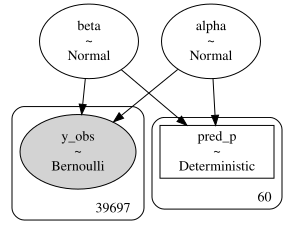

<IPython.core.display.Javascript object>

In [34]:
pm.model_to_graphviz(logistic_model)

In [35]:
with logistic_model:
    idata = pm.sample(500)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 21 seconds.


<IPython.core.display.Javascript object>

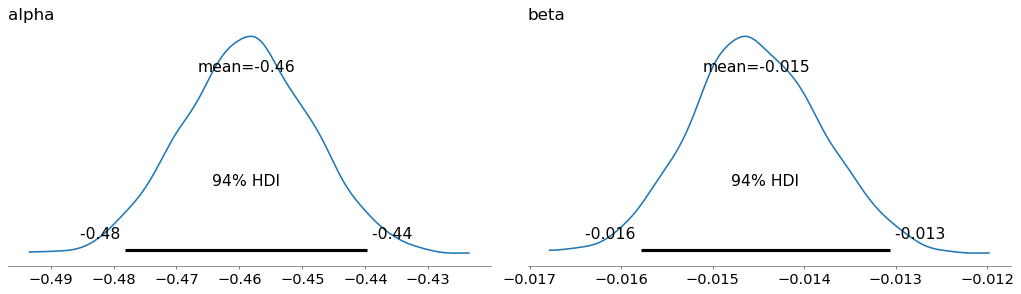

<IPython.core.display.Javascript object>

In [38]:
pm.plot_posterior(idata, var_names=["alpha", "beta"])
plt.tight_layout()

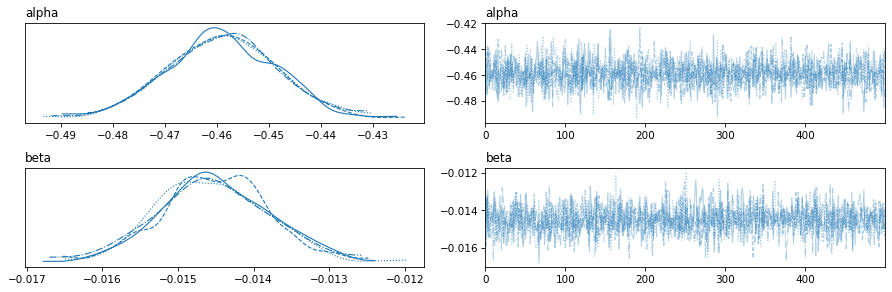

<IPython.core.display.Javascript object>

In [40]:
pm.plot_trace(idata, var_names=["alpha", "beta"])
plt.tight_layout()

In [41]:
pm.summary(idata, var_names=["alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.459,0.010,-0.478,-0.440,0.0,0.0,1981.0,1481.0,1.0
beta,-0.015,0.001,-0.016,-0.013,0.0,0.0,1802.0,1541.0,1.0


<IPython.core.display.Javascript object>

In [73]:
def summarize_dataarray(arr):
    """Display dimensions, and shape of an xarray DataArray."""
    summary = pd.DataFrame({"Dimension": arr.dims, "Size": arr.shape})
    return summary

<IPython.core.display.Javascript object>

In [74]:
# Extract the predicted probabilities for each year in year_range
predicted_probs = idata.posterior["pred_p"]  # shape: (chain, draw, year)
summarize_dataarray(predicted_probs)

,Dimension,Size
Axis,,
0,chain,4
1,draw,500
2,pred_p_dim_0,60


<IPython.core.display.Javascript object>

In [75]:
# Combine chains and draws into a single dimension (flatten to just samples)
stacked_probs = predicted_probs.stack(sample=("chain", "draw"))
summarize_dataarray(stacked_probs)

,Dimension,Size
Axis,,
0,pred_p_dim_0,60
1,sample,2000


<IPython.core.display.Javascript object>

In [77]:
# Randomly select 100 samples
idx = np.random.choice(stacked_probs.sample.size, size=100, replace=False)
sampled_probs = stacked_probs.isel(sample=idx)
summarize_dataarray(sampled_probs)

,Dimension,Size
Axis,,
0,pred_p_dim_0,60
1,sample,100


<IPython.core.display.Javascript object>

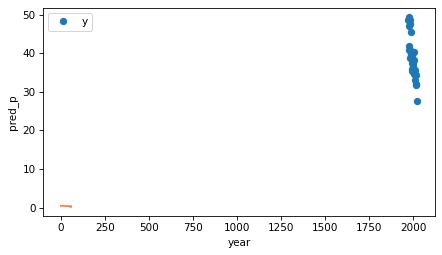

<IPython.core.display.Javascript object>

In [83]:
sampled_probs.plot.line(x="pred_p_dim_0", color="C1", alpha=0.01, add_legend=False)
time_series.plot(style="o")
decorate()

In [80]:
def get_sample(idata, var_name):
    """Extract a posterior sample from idata

    idata: InferenceData object
    var_name: string

    returns: NumPy array
    """
    return idata.posterior[var_name].values.flatten()

<IPython.core.display.Javascript object>

<Axes: xlabel='year'>

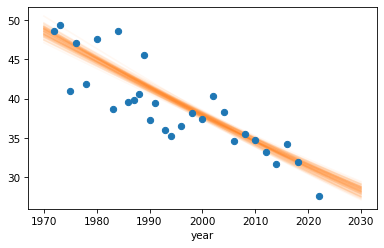

<IPython.core.display.Javascript object>

In [81]:
from scipy.special import expit

# Range of years to predict
years = np.arange(1970, 2031)

# Center years the same way we did in the model
year_centered = years - gss["year"].mean()

# Collect posterior draws of alpha and beta
alpha_samples = get_sample(idata, "alpha")
beta_samples = get_sample(idata, "beta")

# Sample 100 from the posterior
idx = np.random.choice(len(alpha_samples), size=100, replace=False)
alpha_samples = alpha_samples[idx]
beta_samples = beta_samples[idx]

for alpha, beta in zip(alpha_samples, beta_samples):
    logits = alpha + beta * year_centered
    probs = expit(logits) * 100
    plt.plot(years, probs, color="C1", alpha=0.05)

time_series.plot(style="o")

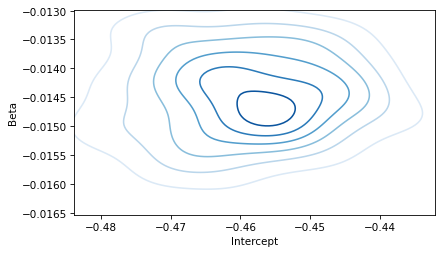

<IPython.core.display.Javascript object>

In [82]:
from utils import joint_contour

joint_contour(alpha_samples, beta_samples)
decorate(xlabel="Intercept", ylabel="Beta")

## Categorical predictors

In [31]:
value_counts(gss["partyid3"])

,counts
values,
0.0,25439
1.0,26705
2.0,18338
NaN,1908


<IPython.core.display.Javascript object>

In [23]:
data = gss.dropna(subset=["y", "year", "partyid3"])
data.shape

(39697, 59)

<IPython.core.display.Javascript object>

In [24]:
y = data["y"].values
year = data["year"].values

year = year - year.mean()
partyid3 = data["partyid3"].astype(int).values

with pm.Model() as logistic_model2:
    # Party-specific intercepts (one for each party)
    alpha = pm.Normal("alpha", 0, 1, shape=3)

    # Shared slope for year (assuming effect of year is the same across parties)
    beta = pm.Normal("beta", 0, 1)

    # Linear predictor (log-odds)
    logits = alpha[partyid3] + beta * year

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y)

<IPython.core.display.Javascript object>

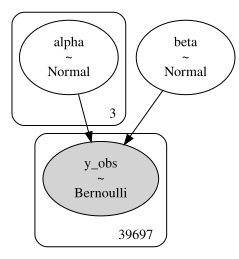

<IPython.core.display.Javascript object>

In [25]:
pm.model_to_graphviz(logistic_model2)

In [26]:
with logistic_model2:
    idata = pm.sample(500)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 40 seconds.


<IPython.core.display.Javascript object>

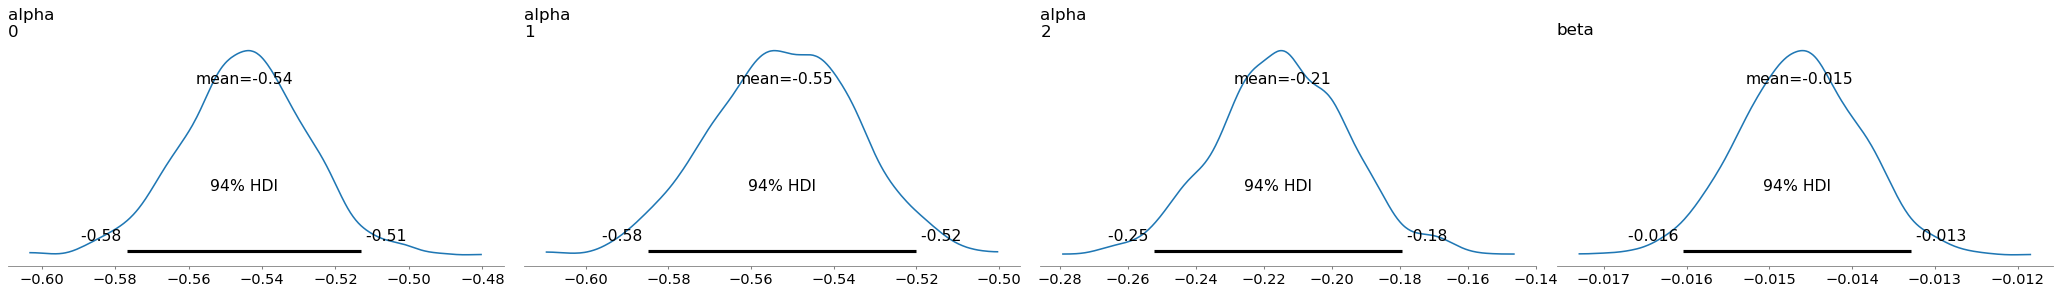

<IPython.core.display.Javascript object>

In [27]:
pm.plot_posterior(idata)
plt.tight_layout()

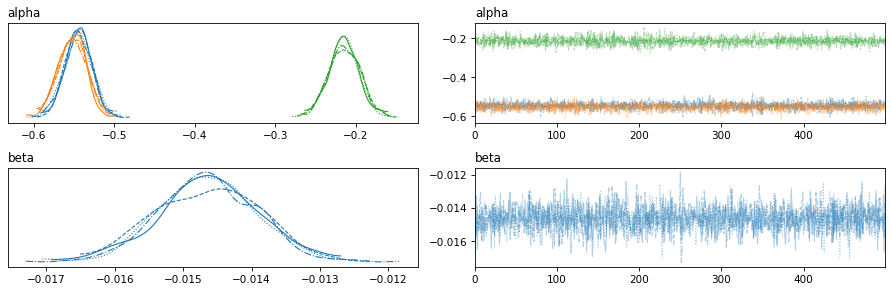

<IPython.core.display.Javascript object>

In [28]:
pm.plot_trace(idata)
plt.tight_layout()

In [29]:
pm.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],-0.545,0.017,-0.577,-0.513,0.0,0.0,3885.0,1650.0,1.00
alpha[1],-0.552,0.017,-0.585,-0.520,0.0,0.0,3814.0,1567.0,1.00
alpha[2],-0.215,0.019,-0.252,-0.179,0.0,0.0,3772.0,1284.0,1.01
beta,-0.015,0.001,-0.016,-0.013,0.0,0.0,3226.0,1716.0,1.00


<IPython.core.display.Javascript object>